In [36]:
# Import the pandas library and give it the nickname 'pd' for easier typing
import pandas as pd

# Import numpy for math operations, nicknamed 'np'
import numpy as np

# Import matplotlib's plotting module, nicknamed 'plt'
import matplotlib.pyplot as plt

# Import seaborn for nicer, easier-to-make charts, nicknamed 'sns'
import seaborn as sns

# 1. Business Understanding
Goal: Predict the obesity class based on various lifestyle factors

# 2. Data Understanding

## 2.1 Load dataset

In [37]:
## Read *.csv file into pandas DataFrame
FILE_PATH = 'data sets/obesity.csv'
df = pd.read_csv(FILE_PATH)
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


## 2.2 Summary Statistics

In [38]:
## Understand the type of variable for each column
df.describe(include = 'all')

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2111,2111.000000,2111.000000,2111.000000,2111,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,NaN,NaN,NaN,1726,1866,NaN,NaN,1765,2067,NaN,2015,NaN,NaN,1401,1580,351
mean,NaN,24.312600,1.701677,86.586058,NaN,NaN,2.419043,2.685628,NaN,NaN,2.008011,NaN,1.010298,0.657866,NaN,NaN,NaN
std,NaN,6.345968,0.093305,26.191172,NaN,NaN,0.533927,0.778039,NaN,NaN,0.612953,NaN,0.850592,0.608927,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,19.947192,1.630000,65.473343,NaN,NaN,2.000000,2.658738,NaN,NaN,1.584812,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,NaN,22.777890,1.700499,83.000000,NaN,NaN,2.385502,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625350,NaN,NaN,NaN
75%,NaN,26.000000,1.768464,107.430682,NaN,NaN,3.000000,3.000000,NaN,NaN,2.477420,NaN,1.666678,1.000000,NaN,NaN,NaN


In [39]:
df.info

<bound method DataFrame.info of       Gender        Age    Height      Weight family_history_with_overweight  \
0     Female  21.000000  1.620000   64.000000                            yes   
1     Female  21.000000  1.520000   56.000000                            yes   
2       Male  23.000000  1.800000   77.000000                            yes   
3       Male  27.000000  1.800000   87.000000                             no   
4       Male  22.000000  1.780000   89.800000                             no   
...      ...        ...       ...         ...                            ...   
2106  Female  20.976842  1.710730  131.408528                            yes   
2107  Female  21.982942  1.748584  133.742943                            yes   
2108  Female  22.524036  1.752206  133.689352                            yes   
2109  Female  24.361936  1.739450  133.346641                            yes   
2110  Female  23.664709  1.738836  133.472641                            yes   

     FA

In [40]:
df.tail()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III
2110,Female,23.664709,1.738836,133.472641,yes,yes,3.0,3.0,Sometimes,no,2.863513,no,1.026452,0.714137,Sometimes,Public_Transportation,Obesity_Type_III


In [41]:
## Check for missing data
df.isna().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [86]:
## Check for missing values (other way)
df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

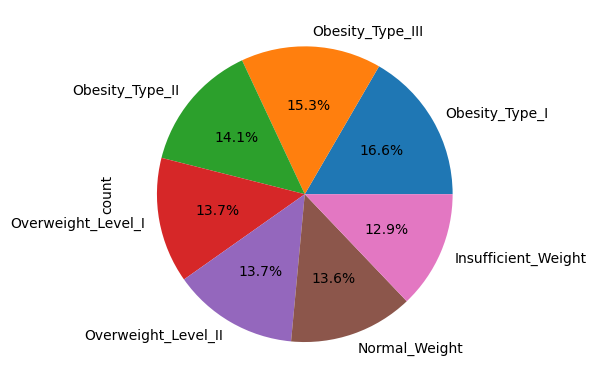

In [43]:
## Understanding distribution of target
col_y = 'NObeyesdad'
df[col_y].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

In [44]:
## Tally unique values
df[col_y].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

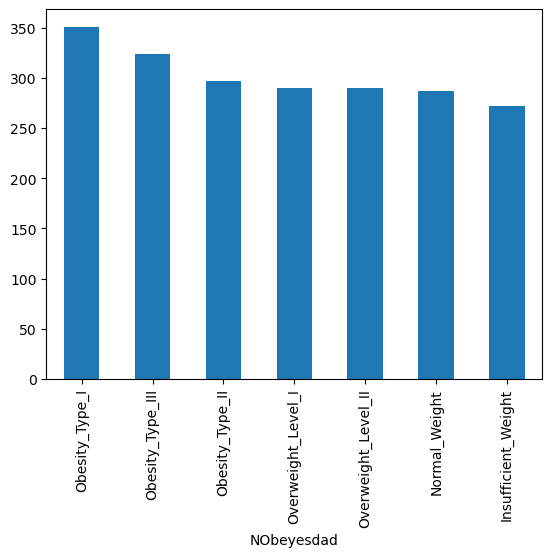

In [45]:
## Plot bar chart
df[col_y].value_counts().plot(kind = 'bar')
plt.show()

### 2.3.1.2 Understanding distribution of features

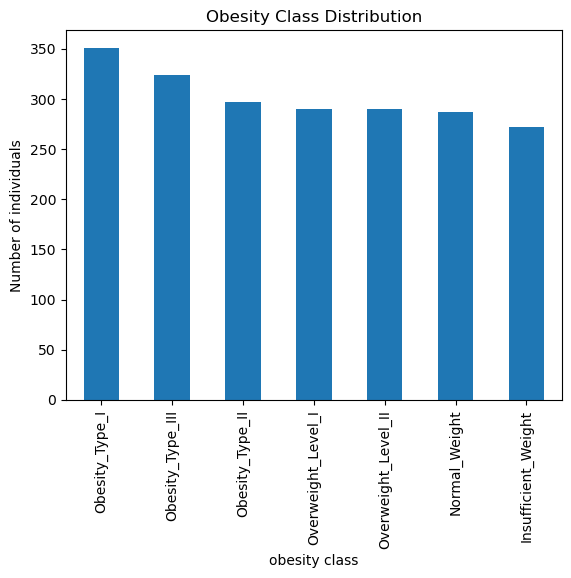

In [46]:
## Understanding distribution of features
df[col_y].value_counts().plot(kind='bar')

plt.title('Obesity Class Distribution')
plt.suptitle('')
plt.xlabel("obesity class")
plt.ylabel("Number of individuals")
plt.show()

### 2.3.2 Understanding relationship between variables

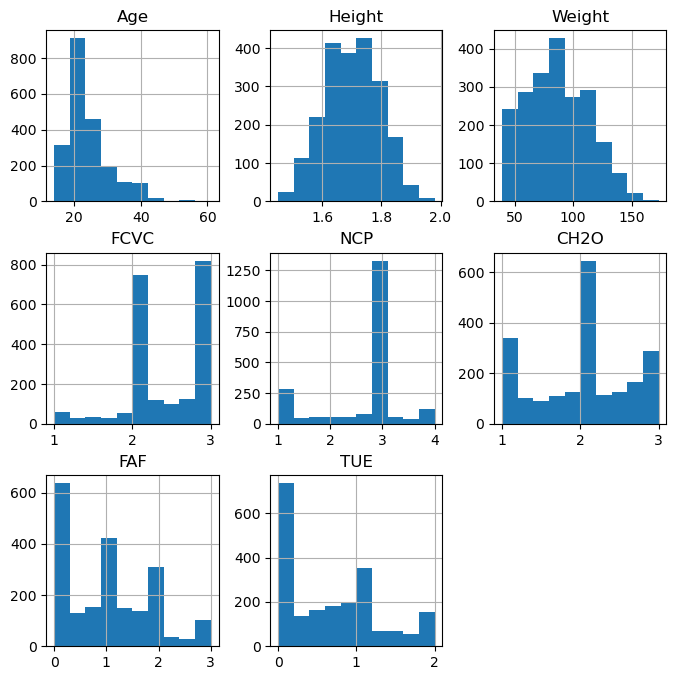

In [47]:
## Understanding relationship between variables
df.hist(layout=(3,3), figsize=(8,8))
plt.show()

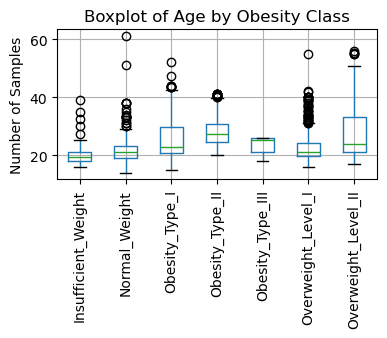

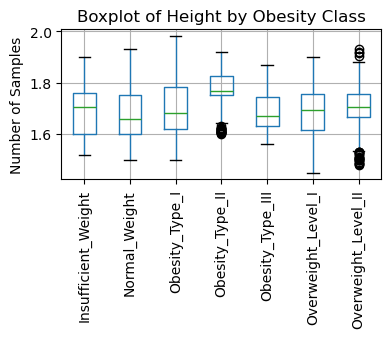

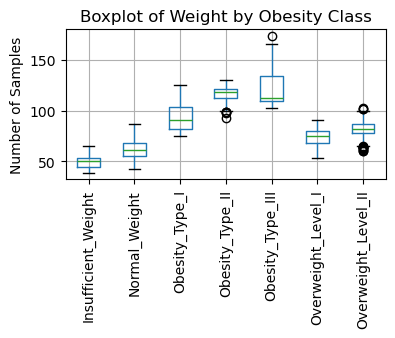

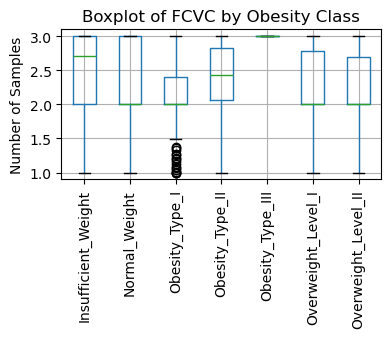

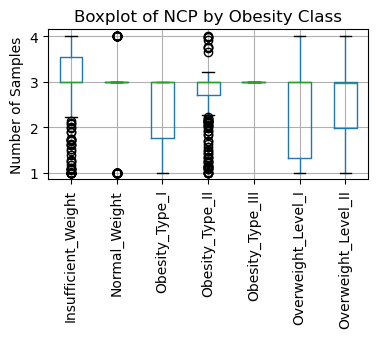

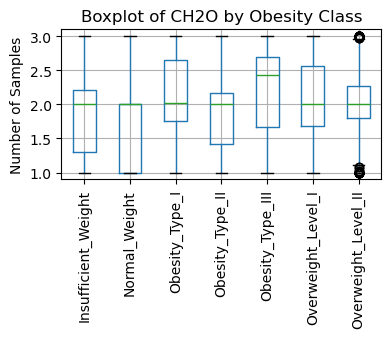

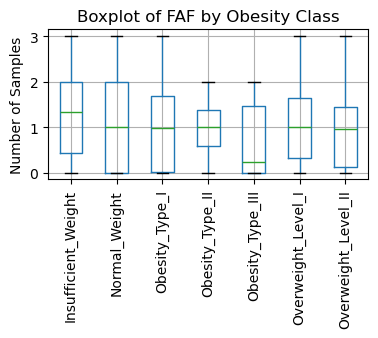

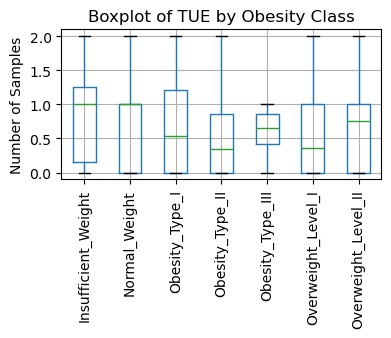

In [48]:

for col in df.columns:
    if df[col].dtype == int or df[col].dtype == float:
        df.boxplot(column=col,
                   by = 'NObeyesdad',
                   grid = True,
                   rot = 90,
                   figsize = (4,2))
        plt.title(f'Boxplot of {col} by Obesity Class')
        plt.suptitle('')
        plt.xlabel('')
        plt.ylabel("Number of Samples")
        plt.show()

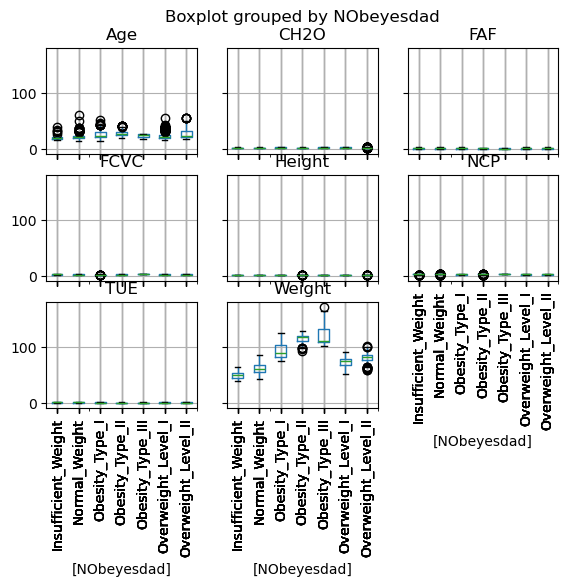

In [49]:
## Boxplot by obesit classes
df.boxplot(by = 'NObeyesdad', 
           rot = 90 ) ## rot: rotate the x-axis labels to be 90 degrees
plt.show()

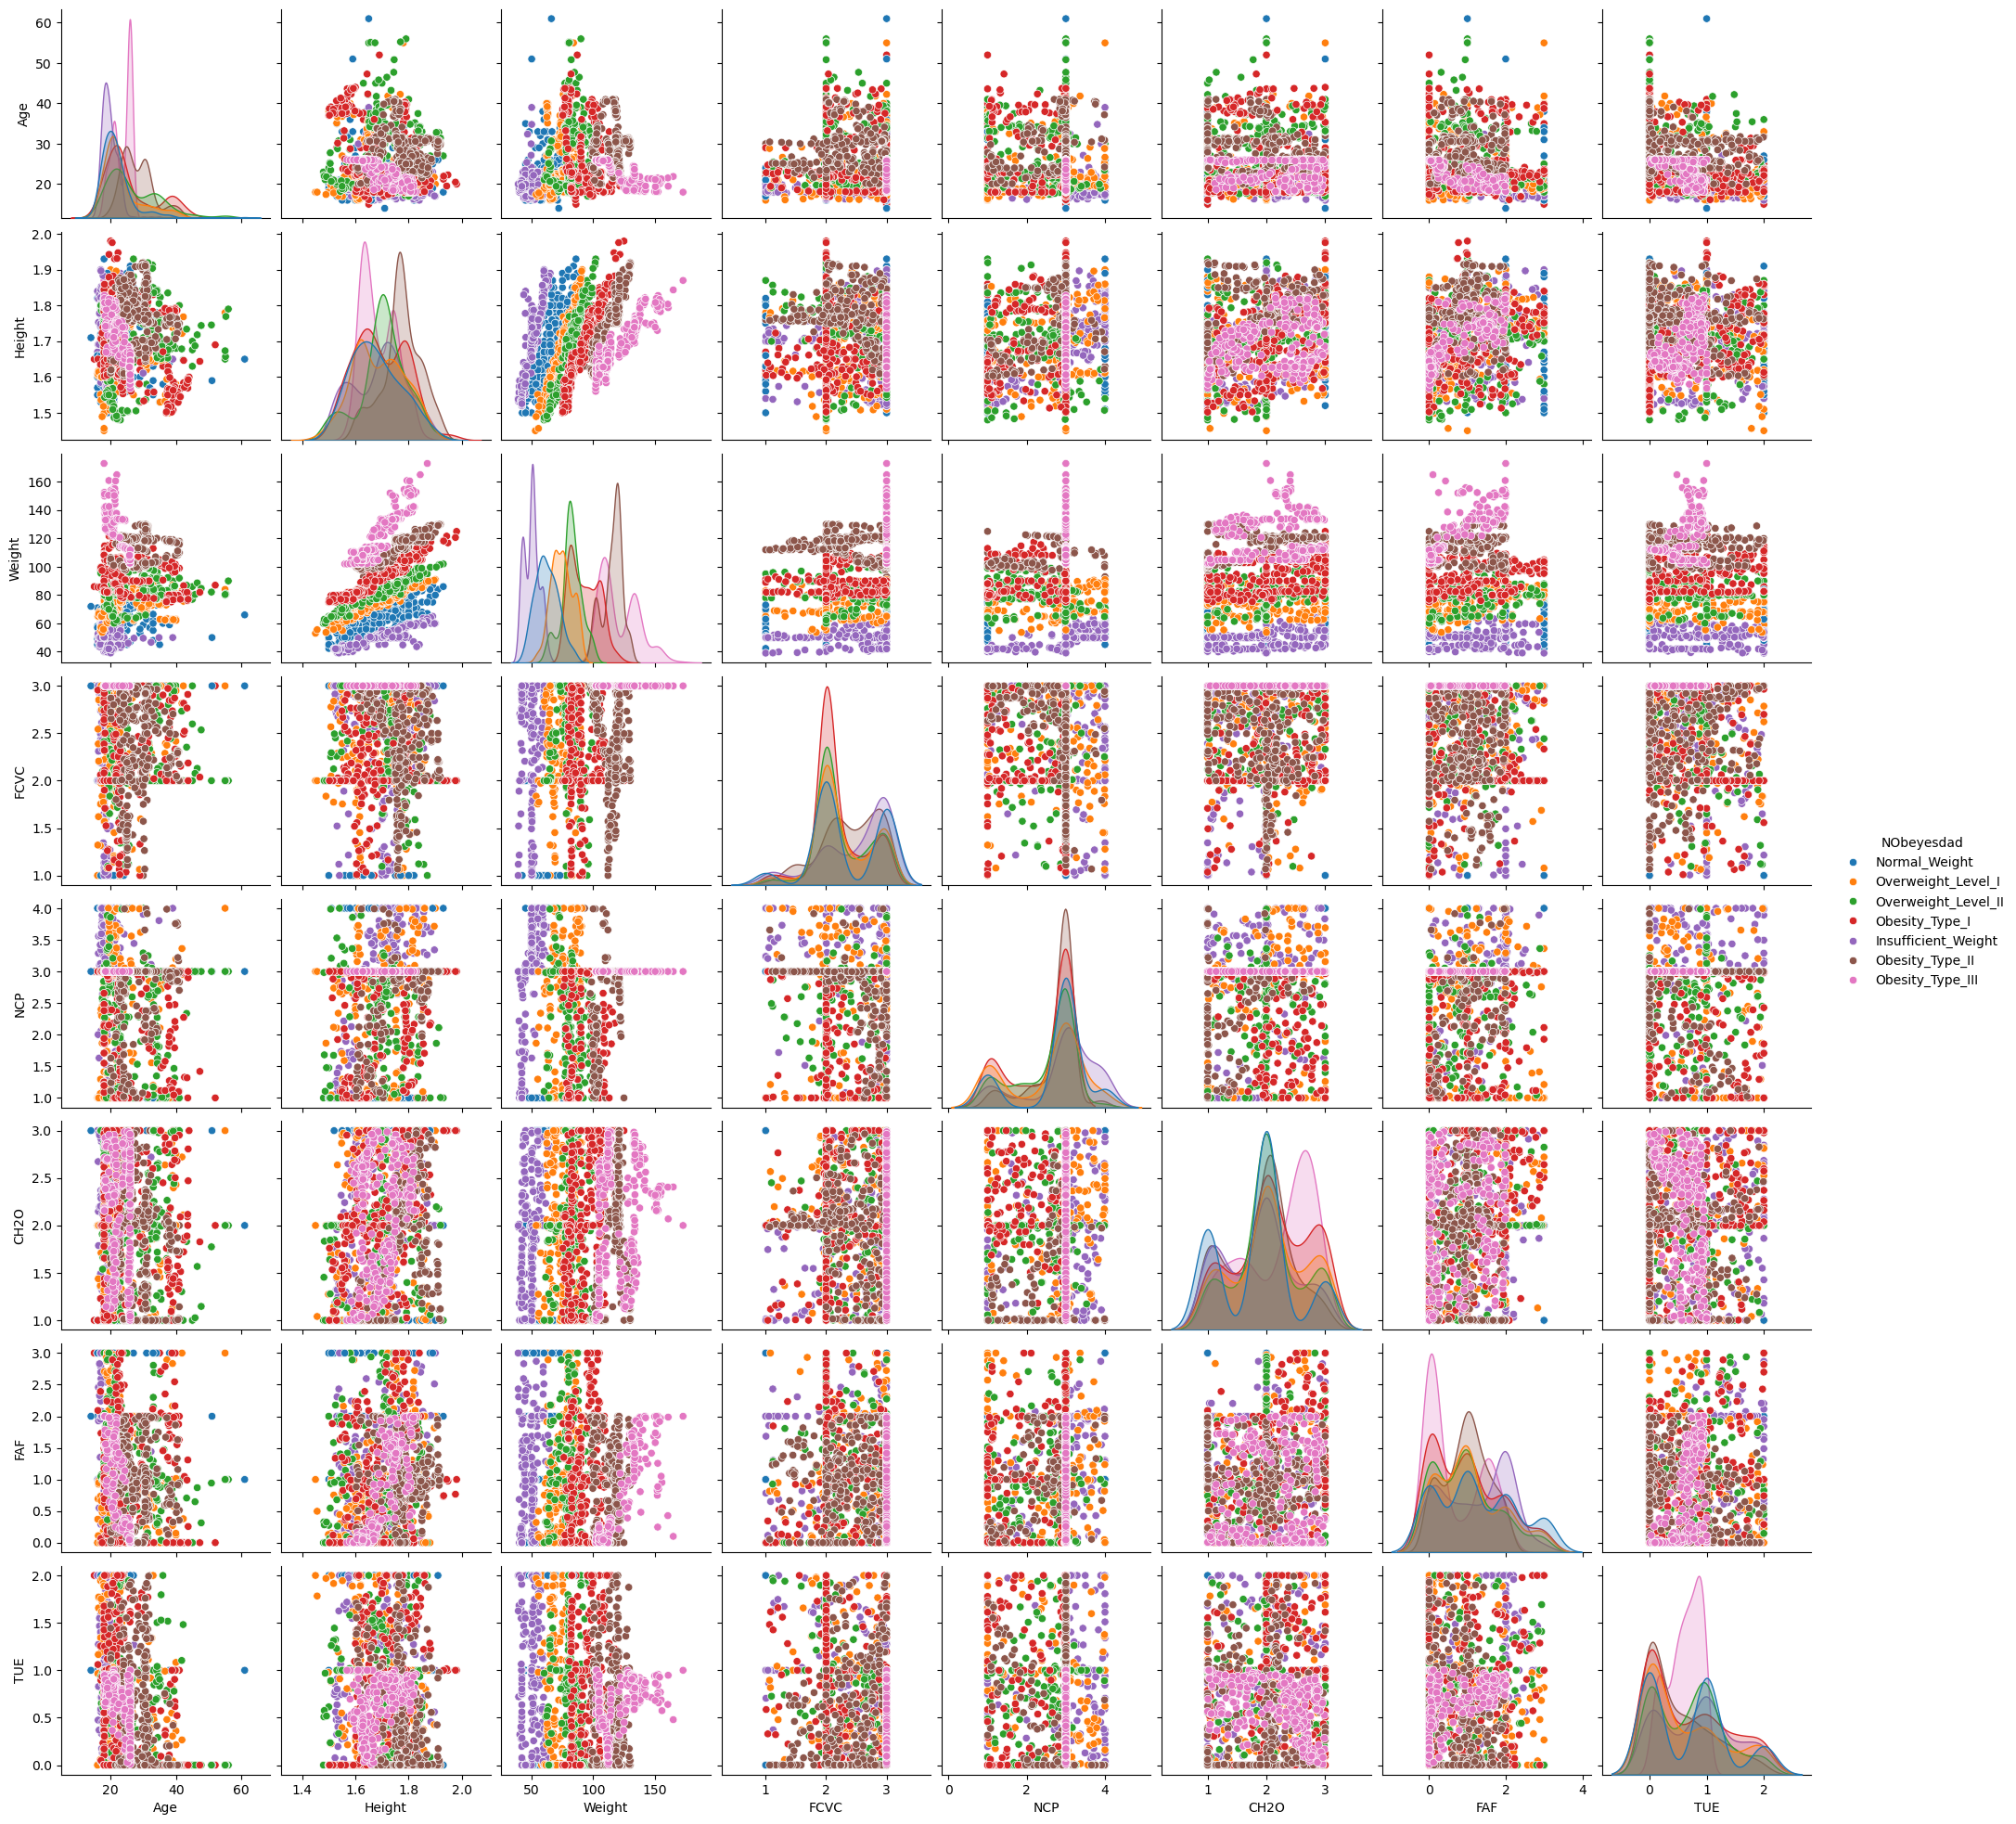

In [50]:
## Plot a pairplot
sns.pairplot(df, hue = col_y)
plt.show()

# 3. Data Preparation

## 3.1 Data Cleaning

In [51]:
## Clean data
## Round age to 0 decimal places(whole number)
df['Age'] = df['Age'].round(0)

## ROund Height and Weight to 2 decimal places
df['Height'] = df['Height'].round(2)
df['Weight'] = df['Weight'].round(2)
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.00,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.00,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.00,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.00,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.80,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,21.0,1.71,131.41,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,22.0,1.75,133.74,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,23.0,1.75,133.69,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.0,1.74,133.35,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [75]:
# Select numeric columns
'''
1. Identify columns that are numeric.
   (Those with decimal places are synthetically generated data.)
2. For each sample, check if the value in any of the columns is zero.
   If it does not, drop that sample (row).
'''
col_numeric = df.select_dtypes(include=['int64', 'float64']).columns # Select numeric columns

col_numeric = [col for col in col_numeric if col not in ['Height', 'Weight']]  # Remove irrelevant columns

df = df[(df[col_numeric] % 1 == 0).all(axis=1)]  # Remove any rows with decimal values, anything false will be removed, any columns that is False will make the whole row False
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.00,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.00,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.00,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.00,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.80,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1356,Female,39.0,1.50,76.64,yes,yes,2.0,3.0,Sometimes,no,1.0,no,0.0,0.0,Sometimes,Automobile,Obesity_Type_I
1405,Male,23.0,1.77,96.08,yes,yes,2.0,3.0,Sometimes,no,3.0,no,3.0,2.0,no,Public_Transportation,Obesity_Type_I
1406,Male,24.0,1.78,97.84,yes,yes,2.0,3.0,Sometimes,no,3.0,no,3.0,2.0,no,Public_Transportation,Obesity_Type_I
1426,Male,23.0,1.75,95.29,yes,yes,2.0,3.0,Sometimes,no,3.0,no,3.0,2.0,no,Public_Transportation,Obesity_Type_I


In [53]:
## Check data types
df.dtypes

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

In [54]:
## Check datatypes for each column
col_categorical = df.select_dtypes(include = ['object']).columns

## Print data about catgorical column
for col in df[col_categorical]:
    print(f'{col} ({df[col].nunique()}): {df[col].unique()}')

Gender (2): ['Female' 'Male']
family_history_with_overweight (2): ['yes' 'no']
FAVC (2): ['no' 'yes']
CAEC (4): ['Sometimes' 'Frequently' 'Always' 'no']
SMOKE (2): ['no' 'yes']
SCC (2): ['no' 'yes']
CALC (4): ['no' 'Sometimes' 'Frequently' 'Always']
MTRANS (5): ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']
NObeyesdad (7): ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


## 3.2 Train-Test Split

In [77]:
## Seperate Features into X and y 
y = df[col_y] ## 'NObeyesdad'

X = df.drop([col_y], axis=1) ## select feature columns, remove the target

## One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)## Remove redundant information)
X

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,1.62,64.00,2.0,3.0,2.0,0.0,1.0,False,True,...,False,False,False,False,False,True,False,False,True,False
1,21.0,1.52,56.00,3.0,3.0,3.0,3.0,0.0,False,True,...,False,True,True,False,True,False,False,False,True,False
2,23.0,1.80,77.00,2.0,3.0,2.0,2.0,1.0,True,True,...,False,False,False,True,False,False,False,False,True,False
3,27.0,1.80,87.00,3.0,3.0,2.0,2.0,0.0,True,False,...,False,False,False,True,False,False,False,False,False,True
4,22.0,1.78,89.80,2.0,1.0,2.0,0.0,0.0,True,False,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1356,39.0,1.50,76.64,2.0,3.0,1.0,0.0,0.0,False,True,...,False,False,False,False,True,False,False,False,False,False
1405,23.0,1.77,96.08,2.0,3.0,3.0,3.0,2.0,True,True,...,False,False,False,False,False,True,False,False,True,False
1406,24.0,1.78,97.84,2.0,3.0,3.0,3.0,2.0,True,True,...,False,False,False,False,False,True,False,False,True,False
1426,23.0,1.75,95.29,2.0,3.0,3.0,3.0,2.0,True,True,...,False,False,False,False,False,True,False,False,True,False


In [78]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 2025)

# 4. Modelling

### 4.2 Train Model

In [81]:
## Initialise and train model

## Model 1 (LOGR)
from sklearn.linear_model import LogisticRegression
logr = LogisticRegression(max_iter=10000)
logr.fit(X_train,y_train) # Train Model

## Model 2 (LDA)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)  ## Train Model

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


# 5. Model Evaluation

In [72]:
## Evaluate model (Logistic Regression)
y_pred_logr = logr.predict(X_test)
from sklearn.metrics import accuracy_score
print(f"Logistic Regression: {accuracy_score(y_test,y_pred_logr)}")
print(f'Accuracy: {accuracy_score(y_test,y_pred_logr)*100:.2f}%')

Logistic Regression: 0.69375
Accuracy: 69.38%


In [73]:
## Evaluate Model (Linear Discriminant Analysis)
y_pred_lda = lda.predict(X_test)
from sklearn.metrics import accuracy_score
print(f'Linear Discriminant Analysis: {accuracy_score(y_test,y_pred_lda)}')
print(f'Accuracy: {accuracy_score(y_pred_lda,y_test)*100:.2f}')

Linear Discriminant Analysis: 0.825
Accuracy: 82.50


In [83]:
## New data
X_unseen = [ ['Female', 21, 1.62, 64, 'yes', 'no', 2, 3,
              'Sometimes', 'no', 2, 'no', 0, 1, 'no',
              'Public_Transportation'] ## sample 1
             ]

## Convert to OHE Pandas dataframe
col_df_X = df.drop(col_y, axis=1).columns ## Select feature columns
col_ohe = X.columns.tolist() ## Select feature column names after OHE

X_unseen = pd.DataFrame(X_unseen, columns=col_df_X) ## Convert to Pandas dataframe
X_unseen = pd.get_dummies(X_unseen, drop_first=True) ## OHE
X_unseen = X_unseen.reindex(columns=col_ohe, fill_value=0) ## Provide OHE columns
display(X_unseen)

## Predict
logr.predict(X_unseen)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21,1.62,64,2,3,2,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


array(['Normal_Weight'], dtype=object)

In [61]:
lda.predict(X_unseen)

array(['Normal_Weight'], dtype='<U19')